# 02 - Decoder performance

Within-subject decoding accuracy for the three feature sets, and where in the
2 s pre-crossing epoch each modality contributes.

The FBCSP number (79.8%) is the benchmark reported by Faller et al. (2019); the
other three come from `01_train_decoders`.

In [1]:
import sys
sys.path.insert(0, "..")   # or: pip install -e .. to import `arousal` directly

import pickle

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

from arousal import config as cfg
from arousal.plotting import BLUE, FS_AN, FS_AX, FS_PAN, FS_TK, panel, tidy

FBCSP_AUC, FBCSP_SEM = 79.8, 7.2      # Faller et al. (2019), Table 1

results = {}
for name in ("physio", "eeg", "all"):
    with open(cfg.RESULTS / f"results_offline_simple_{name}.pkl", "rb") as f:
        results[name] = pickle.load(f)

## Reported statistics

AUC is averaged over repetitions within subject first, so the error bar is the
SEM across the 16 subjects rather than across repetitions.

In [2]:
summary = {}
for name, r in results.items():
    fr = r["final_results"]
    per_subject = fr[:, :, -1, 1].mean(axis=1)
    summary[name] = {
        "auc": per_subject.mean() * 100,
        "sem": per_subject.std() / np.sqrt(len(per_subject)) * 100,
        "acc": fr[:, :, -1, 0].mean() * 100,
        "n_over_80": int((per_subject >= 0.80).sum()),
        "n_over_90": int((per_subject >= 0.90).sum()),
        "n_reps": fr.shape[1],
    }
    s = summary[name]
    print(f"{name:>7}: AUC {s['auc']:.2f} +/- {s['sem']:.2f}  "
          f"ACC {s['acc']:.2f}  |  >=80%: {s['n_over_80']}/16  "
          f">=90%: {s['n_over_90']}/16  ({s['n_reps']} reps)")

 physio: AUC 93.03 +/- 1.00  ACC 85.86  |  >=80%: 16/16  >=90%: 12/16  (10 reps)
    eeg: AUC 85.16 +/- 1.23  ACC 78.18  |  >=80%: 14/16  >=90%: 3/16  (5 reps)
    all: AUC 94.20 +/- 0.70  ACC 87.09  |  >=80%: 16/16  >=90%: 15/16  (5 reps)


In [3]:
# Paired comparisons across decoders, on per-subject mean AUC.
from scipy.stats import ttest_rel

per_subject = {n: results[n]["final_results"][:, :, -1, 1].mean(axis=1)
               for n in results}
for a, b in [("eeg", "physio"), ("physio", "all"), ("eeg", "all")]:
    t, p = ttest_rel(per_subject[b], per_subject[a])
    print(f"{b} vs {a}: t={t:.2f}, p={p:.2e}")

physio vs eeg: t=6.58, p=8.69e-06
all vs physio: t=2.71, p=1.60e-02
all vs eeg: t=8.47, p=4.20e-07


## Figure 1

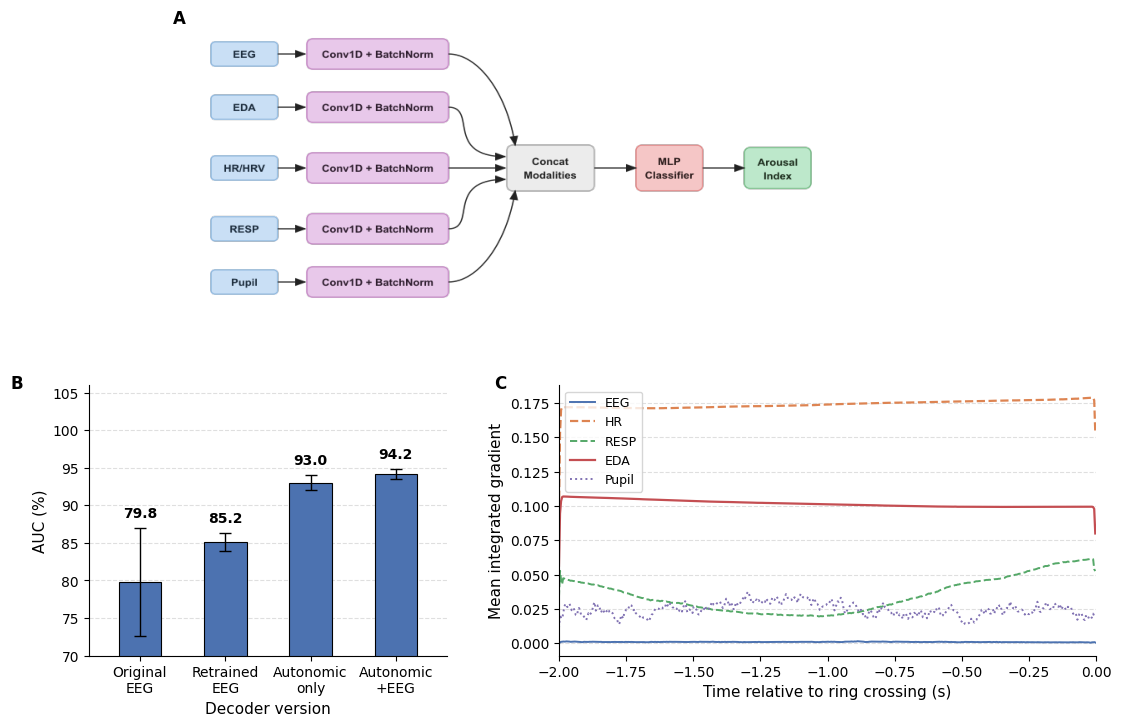

In [4]:
fig = plt.figure(figsize=(13, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1.5],
                       hspace=0.28, wspace=0.25)

# --- A: architecture schematic ------------------------------------------------
ax_a = fig.add_subplot(gs[0, :])
ax_a.imshow(Image.open(cfg.ASSETS / "nn_architecture.png"), aspect="auto")
ax_a.axis("off")
ax_a.set_position([0.2, 0.53, 0.5, 0.38])
panel(ax_a, "A", x=-0.02, y=1.02)

# --- B: AUC by decoder --------------------------------------------------------
ax_b = fig.add_subplot(gs[1, 0])
labels = ["Original\nEEG", "Retrained\nEEG", "Autonomic\nonly", "Autonomic\n+EEG"]
values = [FBCSP_AUC, summary["eeg"]["auc"], summary["physio"]["auc"],
          summary["all"]["auc"]]
errors = [FBCSP_SEM, summary["eeg"]["sem"], summary["physio"]["sem"],
          summary["all"]["sem"]]

x = np.arange(len(labels))
bars = ax_b.bar(x, values, color=BLUE, edgecolor="black", linewidth=0.8,
                width=0.5, zorder=2)
ax_b.errorbar(x, values, yerr=errors, fmt="none", ecolor="black", capsize=4,
              capthick=1.0, linewidth=1.0, zorder=3)
for bar, val, err in zip(bars, values, errors):
    ax_b.text(bar.get_x() + bar.get_width() / 2, val + err + 1.0, f"{val:.1f}",
              ha="center", va="bottom", fontsize=FS_AN, fontweight="bold")

ax_b.set_ylabel("AUC (%)", fontsize=FS_AX)
ax_b.set_xlabel("Decoder version", fontsize=FS_AX)
ax_b.set_xticks(x)
ax_b.set_xticklabels(labels, fontsize=8.5)
ax_b.set_ylim(70, 106)
ax_b.set_xlim(-0.6, len(labels) - 0.4)
tidy(ax_b)
panel(ax_b, "B", x=-0.22)

# --- C: Integrated Gradients over the epoch -----------------------------------
ax_c = fig.add_subplot(gs[1, 1])
imps = results["all"]["imps"]
styles = {
    "EEG":   dict(color="#4C72B0", lw=1.4, ls="-"),
    "HR":    dict(color="#DD8452", lw=1.6, ls="--"),
    "RESP":  dict(color="#55A868", lw=1.4, ls="--"),
    "EDA":   dict(color="#C44E52", lw=1.6, ls="-"),
    "Pupil": dict(color="#8172B3", lw=1.4, ls=":"),
}
t = np.linspace(-2, 0, imps.shape[-1])
for name, chans in cfg.MODALITIES_ALL.items():
    # Drop the final sample: it carries an edge artefact from the conv padding.
    ax_c.plot(t[:-1], imps[chans].mean(axis=0)[:-1], label=name, **styles[name])

ax_c.set_xlabel("Time relative to ring crossing (s)", fontsize=FS_AX)
ax_c.set_ylabel("Mean integrated gradient", fontsize=FS_AX)
ax_c.set_xlim(-2, 0)
tidy(ax_c)
ax_c.legend(fontsize=9, frameon=True, loc="upper left")
panel(ax_c, "C", x=-0.12)

cfg.FIGURES.mkdir(exist_ok=True)
plt.savefig(cfg.FIGURES / "figure_1.png", dpi=300, bbox_inches="tight")
plt.show()

## Attribution by modality

Reported per channel, which is what panel C plots. EEG carries 256 of the 263
input channels, so its *summed* attribution is large while its per-channel
contribution is near zero.

In [5]:
print(f"{'modality':<8}{'channels':>9}{'mean |attr| per channel':>26}{'share of total':>16}")
total = sum(np.abs(imps[c]).sum() for c in cfg.MODALITIES_ALL.values())
for name, chans in cfg.MODALITIES_ALL.items():
    per_channel = np.abs(imps[chans]).mean()
    share = np.abs(imps[chans]).sum() / total * 100
    print(f"  {name:<6}{len(chans):>9}{per_channel:>26.3e}{share:>15.1f}%")

modality channels   mean |attr| per channel  share of total
  EEG         256                 1.287e-03           33.6%
  HR            2                 1.738e-01           35.5%
  RESP          1                 3.539e-02            3.6%
  EDA           2                 1.016e-01           20.7%
  Pupil         2                 3.195e-02            6.5%
